In [44]:
# Import essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Set aesthetics for visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 8)


In [34]:
# Load sample dataset (Titanic dataset)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)


In [38]:
# Display first few rows of the dataset
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,TitleGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,Mr


In [10]:
# Check dataset information
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
# Generate basic summary statistics
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
# Count missing values in each column
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
# Check unique values in categorical columns
for col in df.select_dtypes(include=['object']).columns:
    print(f"\nUnique values in {col}:")
    print(df[col].value_counts())



Unique values in Name:
Name
Dooley, Mr. Patrick                                    1
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
                                                      ..
Hewlett, Mrs. (Mary D Kingcome)                        1
Vestrom, Miss. Hulda Amanda Adolfina                   1
Andersson, Mr. Anders Johan                            1
Saundercock, Mr. William Henry                         1
Bonnell, Miss. Elizabeth                               1
Name: count, Length: 891, dtype: int64

Unique values in Sex:
Sex
male      577
female    314
Name: count, dtype: int64

Unique values in Ticket:
Ticket
347082              7
1601                7
CA. 2343            7
3101295             6
CA 2144             6
                   ..
PC 17590            1
17463               1
330877         

In [13]:
# Univariate Analysis - Summary Statistics
# Calculate statistical measures including skewness for numerical variables
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
stats_df = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Std Dev': df[num_cols].std(),
    'Skewness': df[num_cols].skew(),
    'Kurtosis': df[num_cols].kurt()
})
stats_df.round(2)


,Mean,Median,Std Dev,Skewness,Kurtosis
PassengerId,446.00,446.00,257.35,0.00,-1.20
Survived,0.38,0.00,0.49,0.48,-1.78
Pclass,2.31,3.00,0.84,-0.63,-1.28
Age,29.70,28.00,14.53,0.39,0.18
SibSp,0.52,0.00,1.10,3.70,17.88
Parch,0.38,0.00,0.81,2.75,9.78
Fare,32.20,14.45,49.69,4.79,33.40


In [14]:
# Univariate Analysis - Visualizations
# Distribution of age
plt.figure(figsize=(12, 6))


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Text(0.5, 0, 'Age')

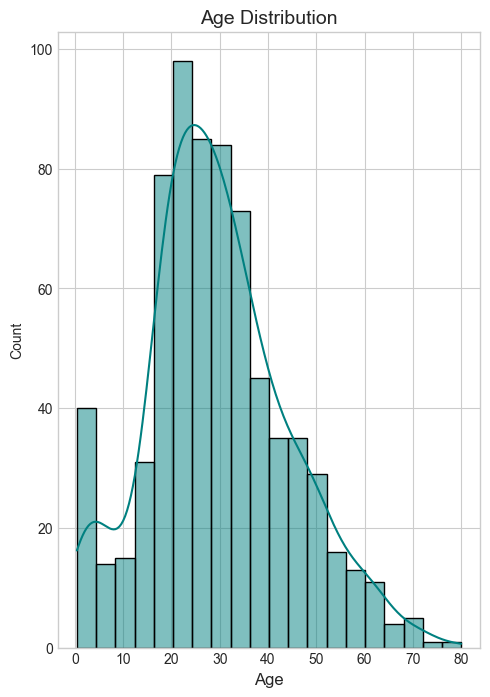

In [15]:
# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(df['Age'].dropna(), kde=True, color='teal')
plt.title('Age Distribution', fontsize=14)
plt.xlabel('Age', fontsize=12)


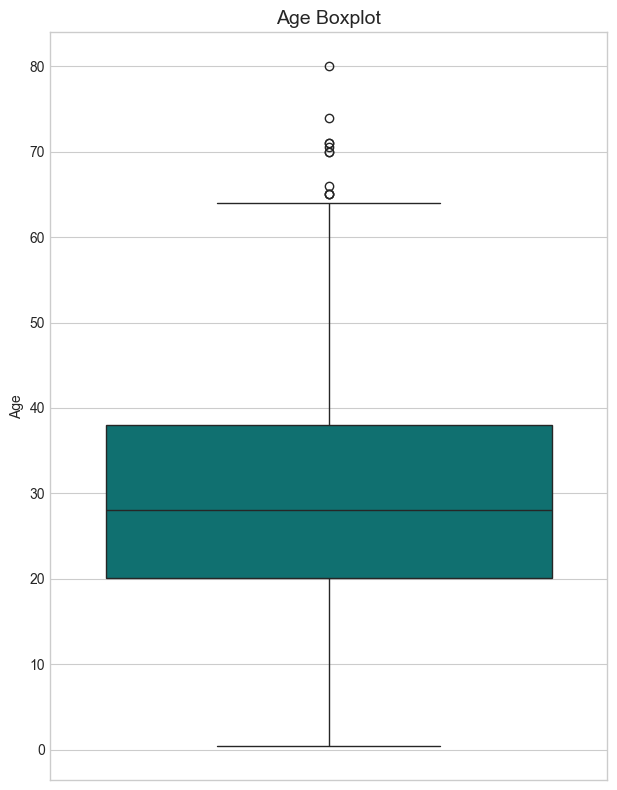

In [13]:
# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Age'].dropna(), color='teal')
plt.title('Age Boxplot', fontsize=14)
plt.tight_layout()
plt.show()


In [14]:
# Distribution of fare
plt.figure(figsize=(12, 6))


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Text(0.5, 0, 'Fare')

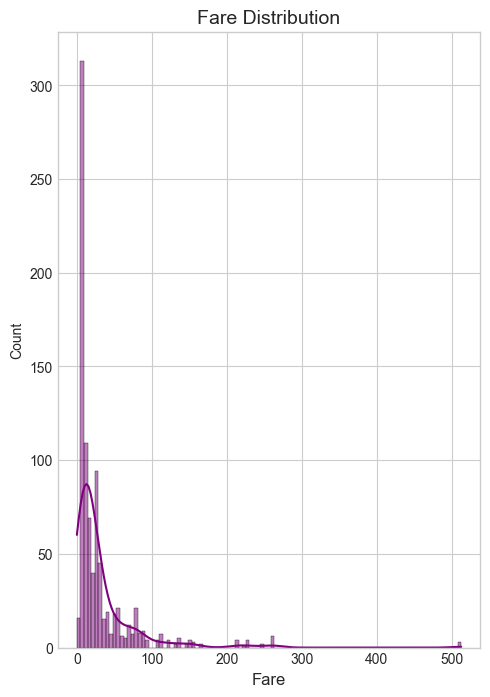

In [15]:
# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(df['Fare'], kde=True, color='purple')
plt.title('Fare Distribution', fontsize=14)
plt.xlabel('Fare', fontsize=12)


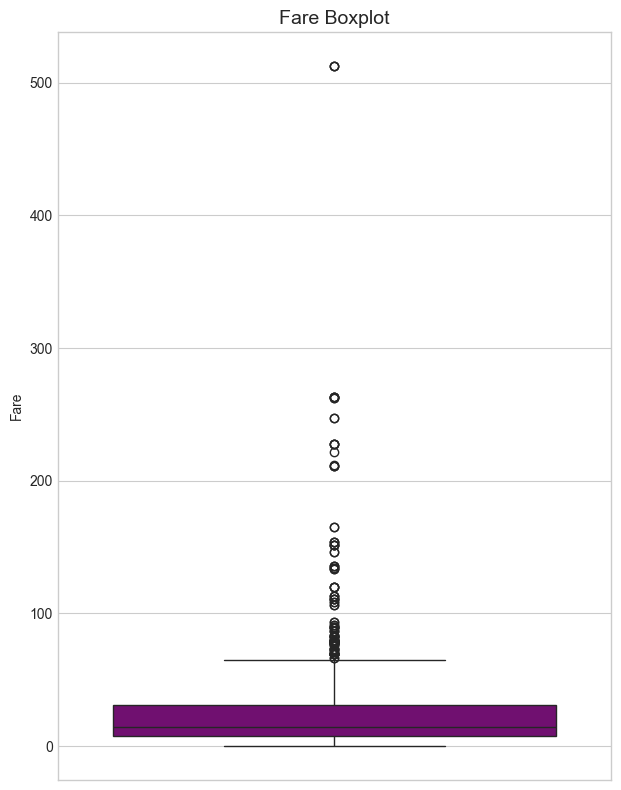

In [16]:
# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Fare'], color='purple')
plt.title('Fare Boxplot', fontsize=14)
plt.tight_layout()
plt.show()


In [17]:
# Categorical value counts with visualization
plt.figure(figsize=(15, 12))


<Figure size 1500x1200 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

Text(0.5, 1.0, 'Passenger Class Distribution')

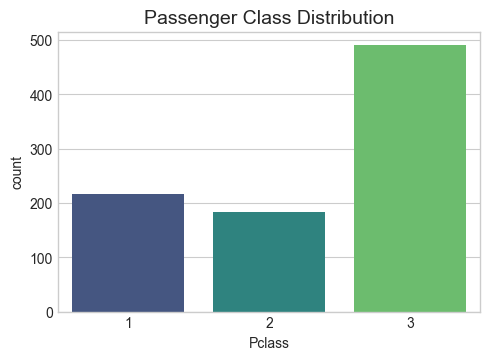

In [17]:
# Passenger class distribution
plt.subplot(2, 2, 1)
sns.countplot(x='Pclass', data=df, palette='viridis')
plt.title('Passenger Class Distribution', fontsize=14)


Text(0.5, 1.0, 'Gender Distribution')

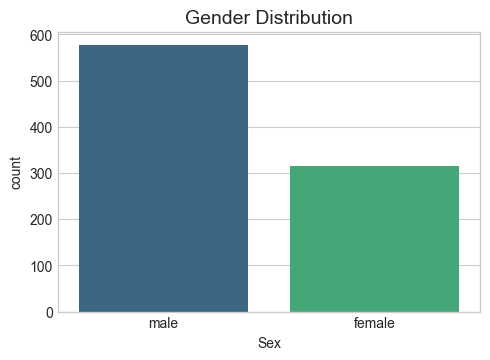

In [18]:
# Gender distribution
plt.subplot(2, 2, 2)
sns.countplot(x='Sex', data=df, palette='viridis')
plt.title('Gender Distribution', fontsize=14)


Text(0.5, 1.0, 'Port of Embarkation')

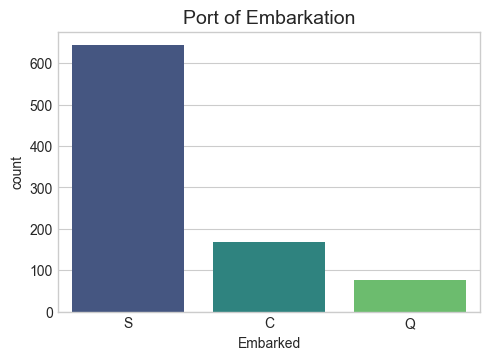

In [19]:
# Embarked distribution
plt.subplot(2, 2, 3)
sns.countplot(x='Embarked', data=df, palette='viridis')
plt.title('Port of Embarkation', fontsize=14)


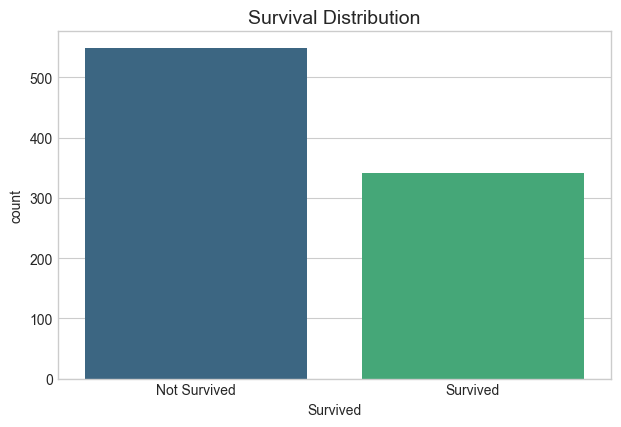

In [20]:
# Survival distribution
plt.subplot(2, 2, 4)
sns.countplot(x='Survived', data=df, palette='viridis')
plt.title('Survival Distribution', fontsize=14)
plt.xticks([0, 1], ['Not Survived', 'Survived'])

plt.tight_layout()
plt.show()


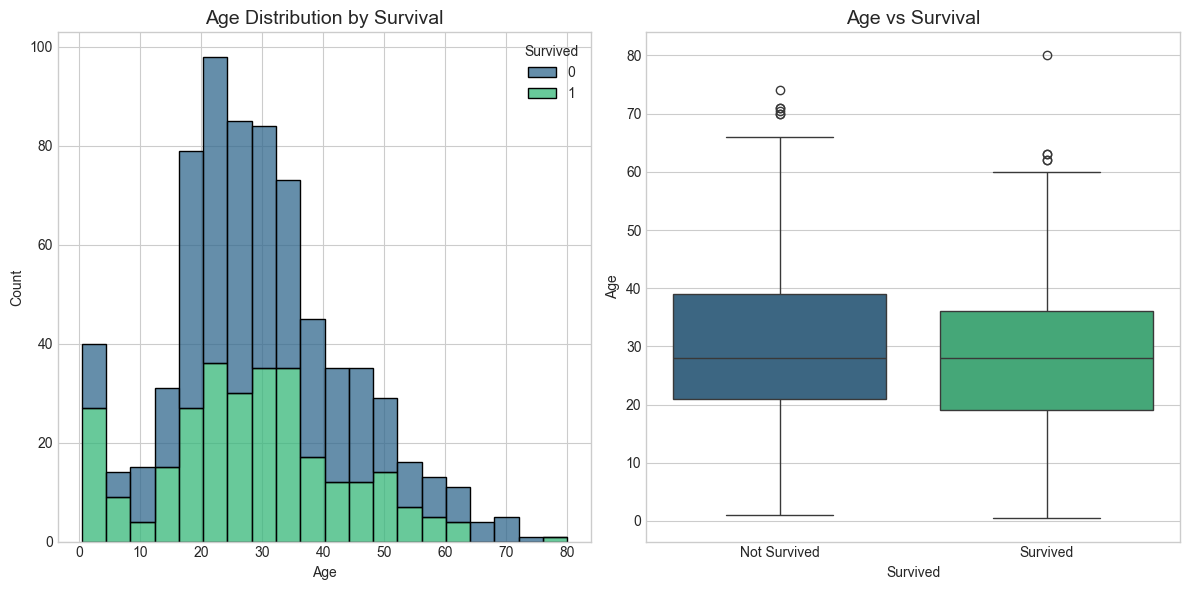

In [21]:
# Bivariate Analysis
# Age distribution by survival status
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Age', hue='Survived', multiple='stack', palette='viridis')
plt.title('Age Distribution by Survival', fontsize=14)

plt.subplot(1, 2, 2)
sns.boxplot(x='Survived', y='Age', data=df, palette='viridis')
plt.title('Age vs Survival', fontsize=14)
plt.xticks([0, 1], ['Not Survived', 'Survived'])

plt.tight_layout()
plt.show()


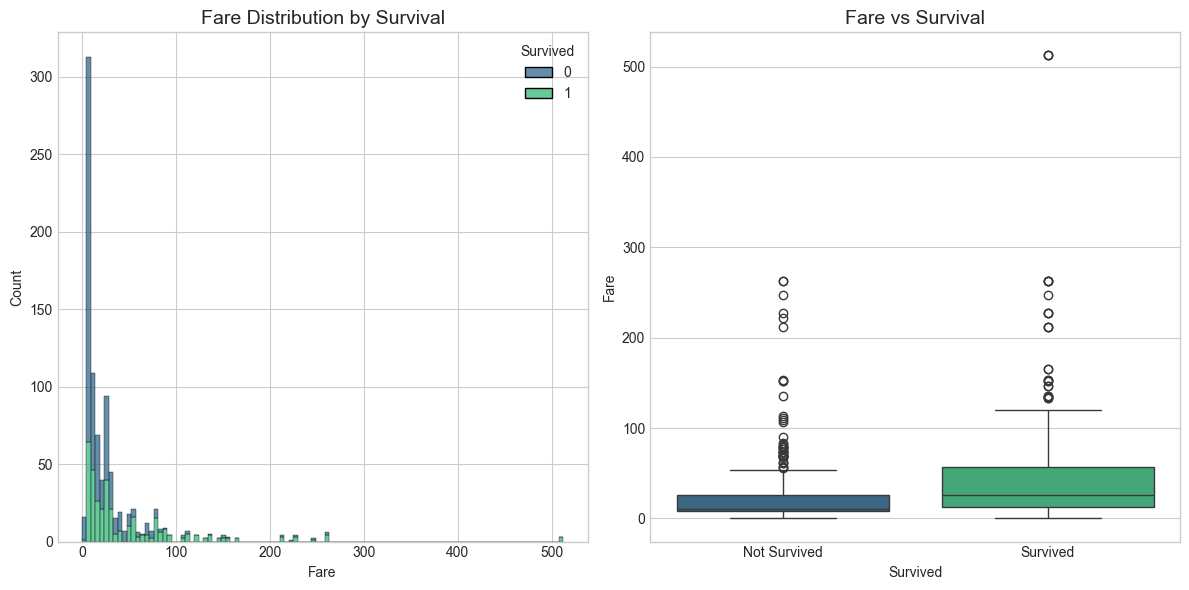

In [22]:
# Fare distribution by survival status
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Fare', hue='Survived', multiple='stack', palette='viridis')
plt.title('Fare Distribution by Survival', fontsize=14)

plt.subplot(1, 2, 2)
sns.boxplot(x='Survived', y='Fare', data=df, palette='viridis')
plt.title('Fare vs Survival', fontsize=14)
plt.xticks([0, 1], ['Not Survived', 'Survived'])

plt.tight_layout()
plt.show()


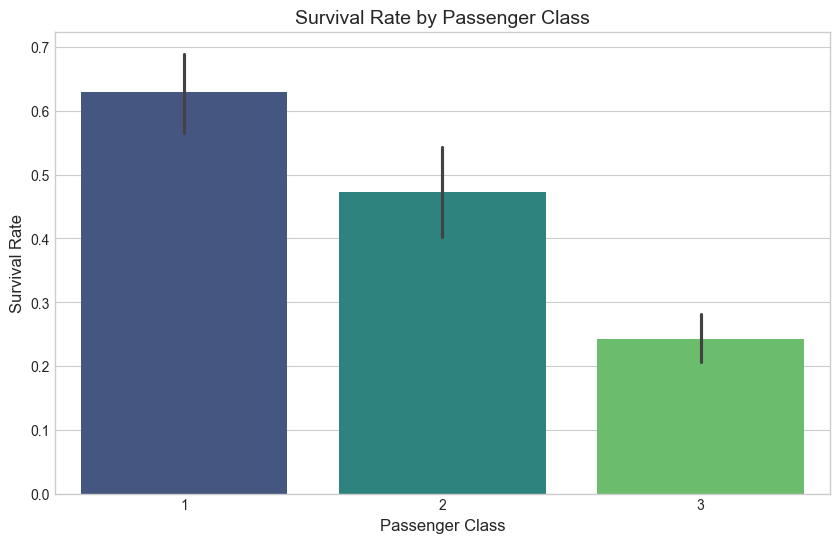

In [24]:
# Survival rate by Passenger Class
plt.figure(figsize=(10, 6))
sns.barplot(x='Pclass', y='Survived', data=df, estimator=np.mean, palette='viridis')
plt.title('Survival Rate by Passenger Class', fontsize=14)
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.show()


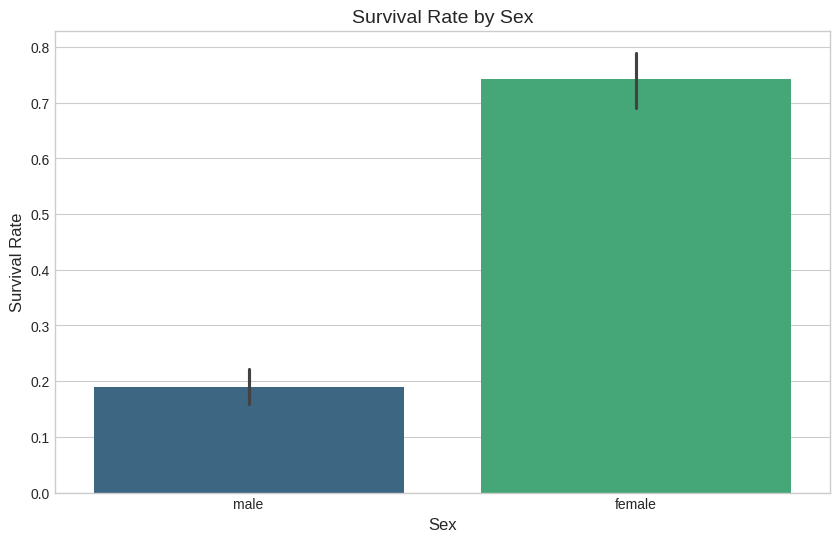

In [ ]:
# Survival rate by Sex
plt.figure(figsize=(10, 6))
sns.barplot(x='Sex', y='Survived', data=df, estimator=np.mean, palette='viridis')
plt.title('Survival Rate by Sex', fontsize=14)
plt.xlabel('Sex', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.show()


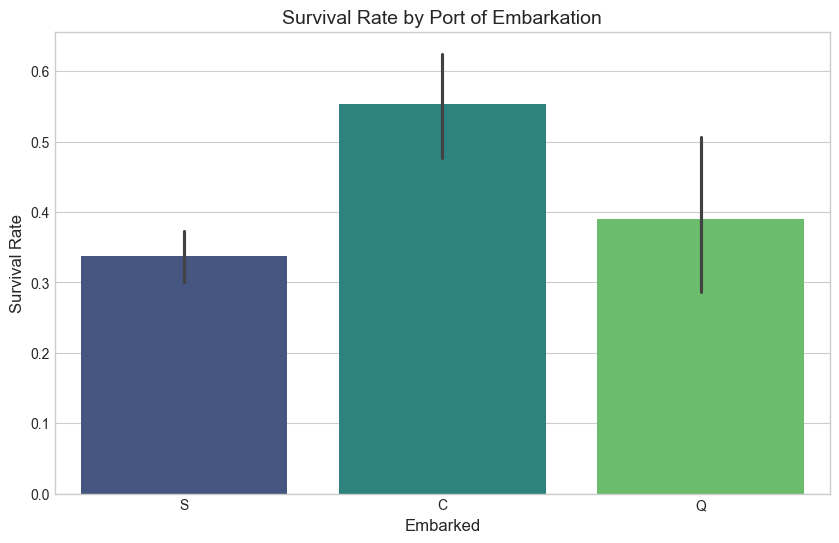

In [25]:
# Survival rate by Embarked
plt.figure(figsize=(10, 6))
sns.barplot(x='Embarked', y='Survived', data=df, estimator=np.mean, palette='viridis')
plt.title('Survival Rate by Port of Embarkation', fontsize=14)
plt.xlabel('Embarked', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.show()


In [26]:
# Create a correlation matrix for numerical variables
# Fill missing values for correlation calculation
df_corr = df.select_dtypes(include=['int64', 'float64']).copy()
df_corr.fillna(df_corr.mean(), inplace=True)


In [27]:
# Calculate correlation matrix
corr_matrix = df_corr.corr()


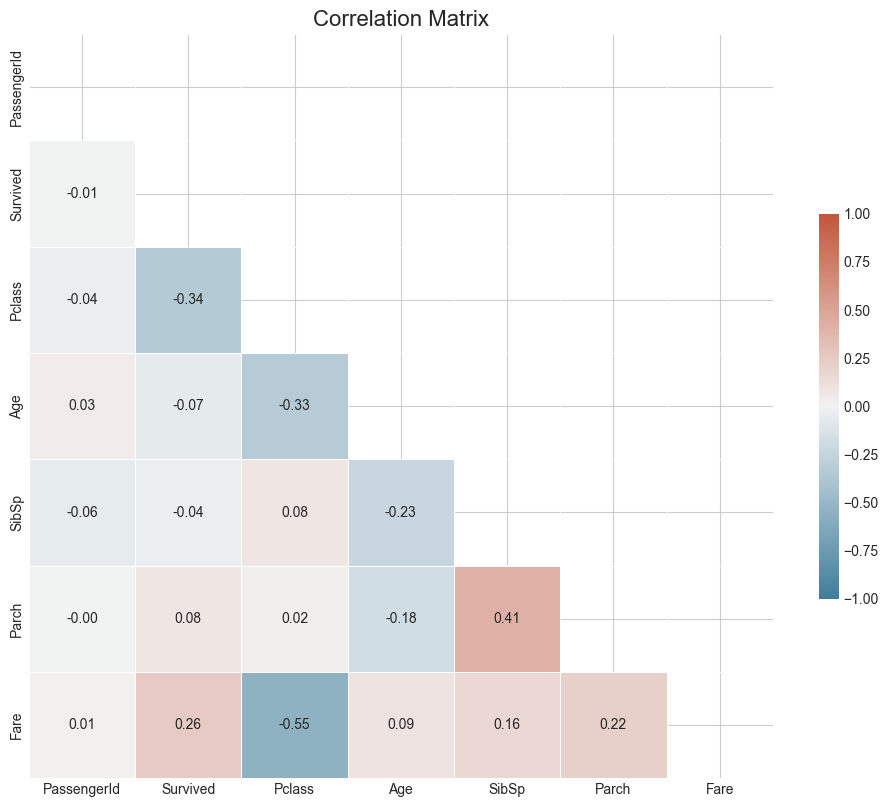

In [28]:
# Visualize correlation matrix
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, annot=True, fmt='.2f', cbar_kws={"shrink": .5})
plt.title('Correlation Matrix', fontsize=16)
plt.show()


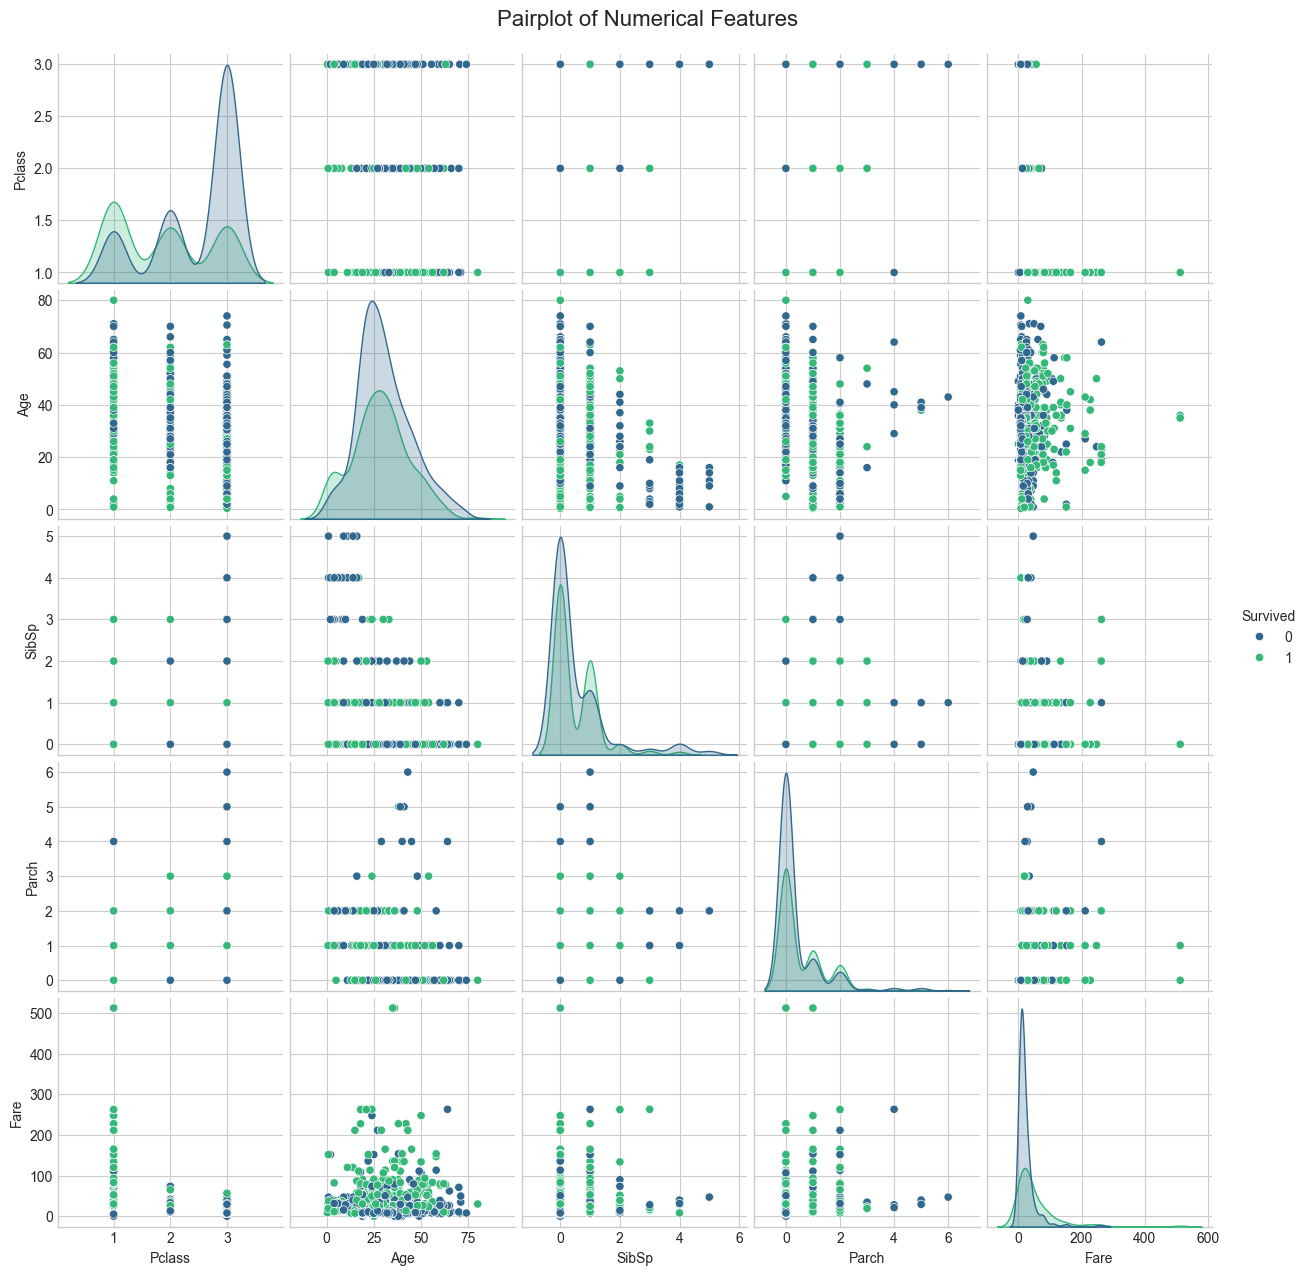

In [29]:
# Pairplot for numerical variables
sns.pairplot(df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].dropna(),
             hue='Survived', palette='viridis', diag_kind='kde')
plt.suptitle('Pairplot of Numerical Features', y=1.02, fontsize=16)
plt.show()


In [30]:
# Outlier Detection using Z-Score for Fare
z_scores = stats.zscore(df['Fare'].dropna())
outliers_z = np.abs(z_scores) > 3
print(f"Number of outliers detected by Z-score (|z| > 3): {outliers_z.sum()}")


Number of outliers detected by Z-score (|z| > 3): 20


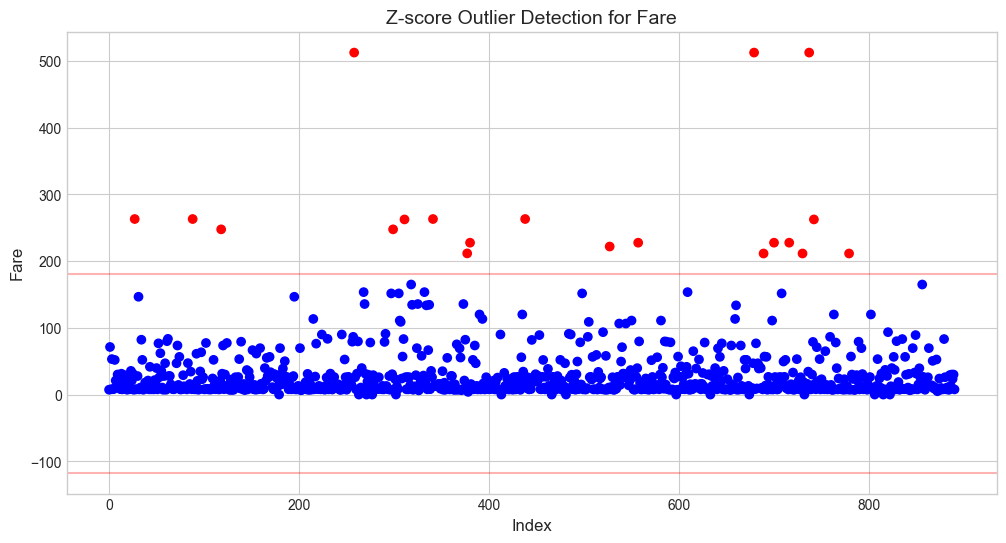

In [31]:
# Visualize Z-score outliers
plt.figure(figsize=(12, 6))
plt.scatter(range(len(df['Fare'].dropna())), df['Fare'].dropna(), c=['red' if x else 'blue' for x in outliers_z])
plt.axhline(y=df['Fare'].mean() + 3*df['Fare'].std(), color='red', linestyle='-', alpha=0.3)
plt.axhline(y=df['Fare'].mean() - 3*df['Fare'].std(), color='red', linestyle='-', alpha=0.3)
plt.title('Z-score Outlier Detection for Fare', fontsize=14)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Fare', fontsize=12)
plt.show()


In [32]:
# Outlier Detection using IQR method for Fare
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = (df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)
print(f"Number of outliers detected by IQR method: {outliers_iqr.sum()}")


Number of outliers detected by IQR method: 116


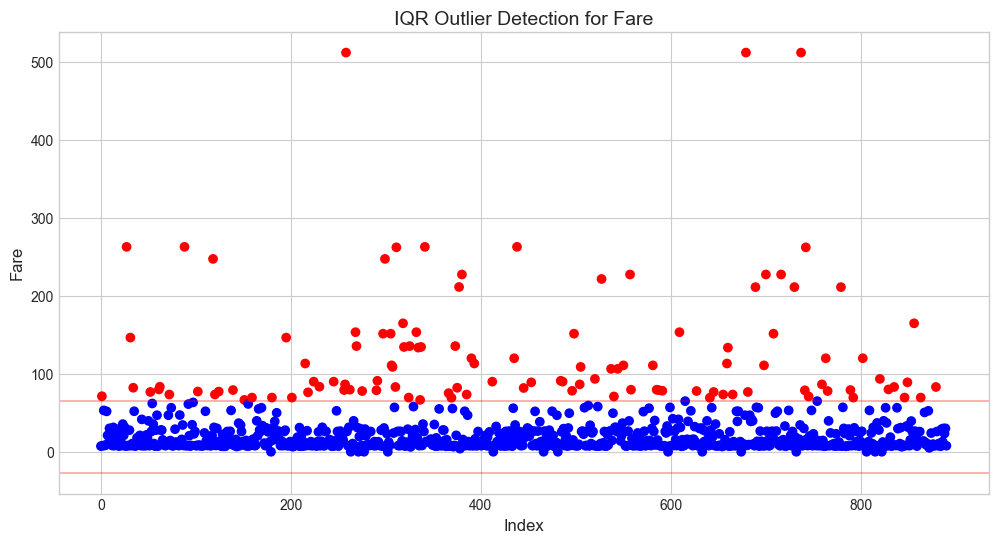

In [33]:
# Visualize IQR outliers
plt.figure(figsize=(12, 6))
plt.scatter(range(len(df['Fare'])), df['Fare'], c=['red' if x else 'blue' for x in outliers_iqr])
plt.axhline(y=upper_bound, color='red', linestyle='-', alpha=0.3)
plt.axhline(y=lower_bound, color='red', linestyle='-', alpha=0.3)
plt.title('IQR Outlier Detection for Fare', fontsize=14)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Fare', fontsize=12)
plt.show()


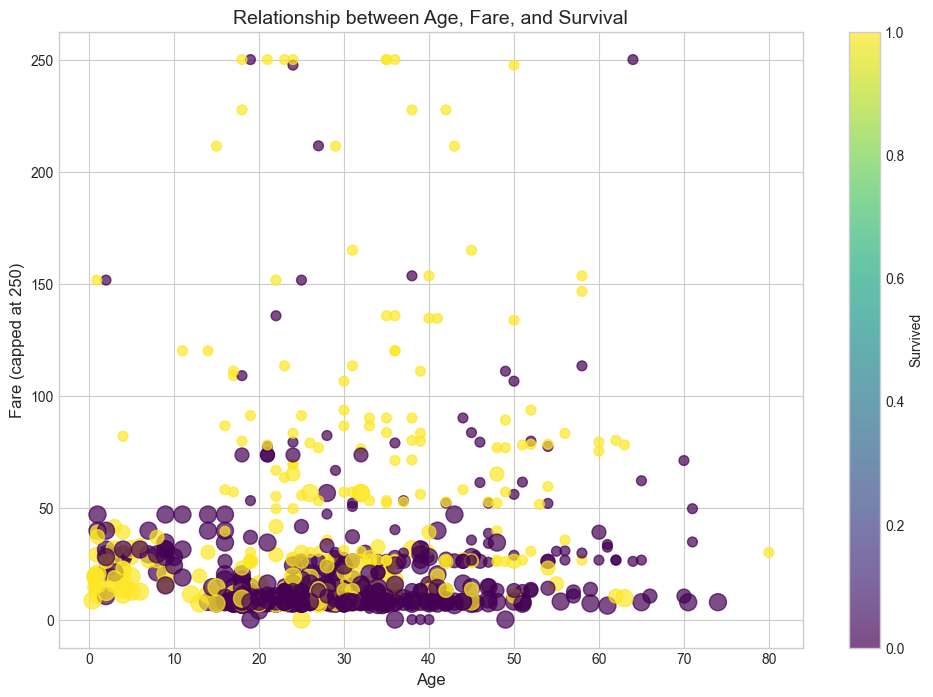

In [34]:
# Visualize relationship between age, fare, and survival
plt.figure(figsize=(12, 8))

# Filter the dataframe to use only rows where Age is not null
age_data = df.dropna(subset=['Age'])

scatter = plt.scatter(age_data['Age'],
                      age_data['Fare'].clip(upper=250),
                      c=age_data['Survived'],
                      cmap='viridis',
                      alpha=0.7,
                      s=age_data['Pclass']*50)

plt.colorbar(scatter, label='Survived')
plt.title('Relationship between Age, Fare, and Survival', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Fare (capped at 250)', fontsize=12)
plt.show()


In [35]:
# Feature Engineering Example - Age Groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100],
                      labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Elderly'])


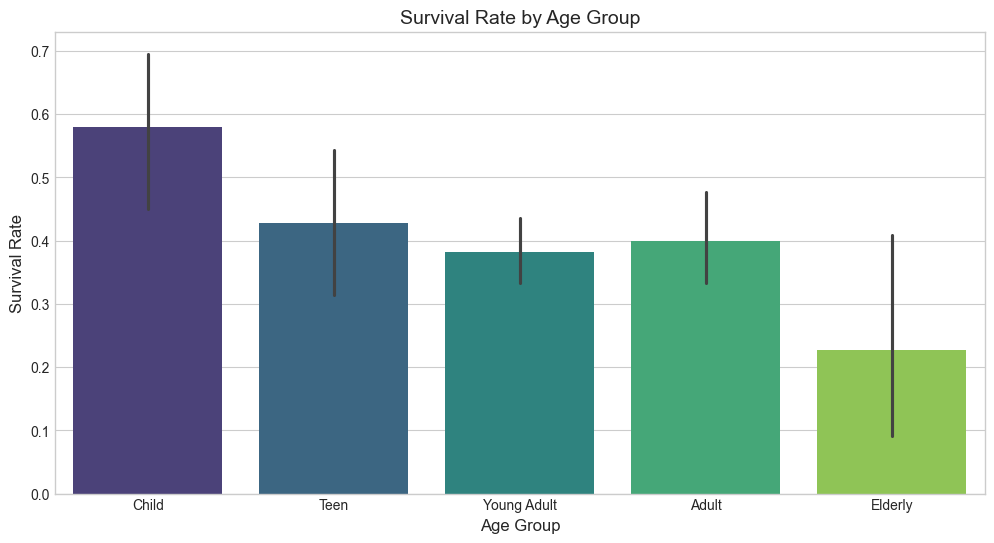

In [36]:
# Survival rate by Age Group
plt.figure(figsize=(12, 6))
sns.barplot(x='AgeGroup', y='Survived', data=df, estimator=np.mean, palette='viridis')
plt.title('Survival Rate by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.show()


In [37]:
# Feature Engineering Example - Fare Categories
df['FareCategory'] = pd.qcut(df['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])

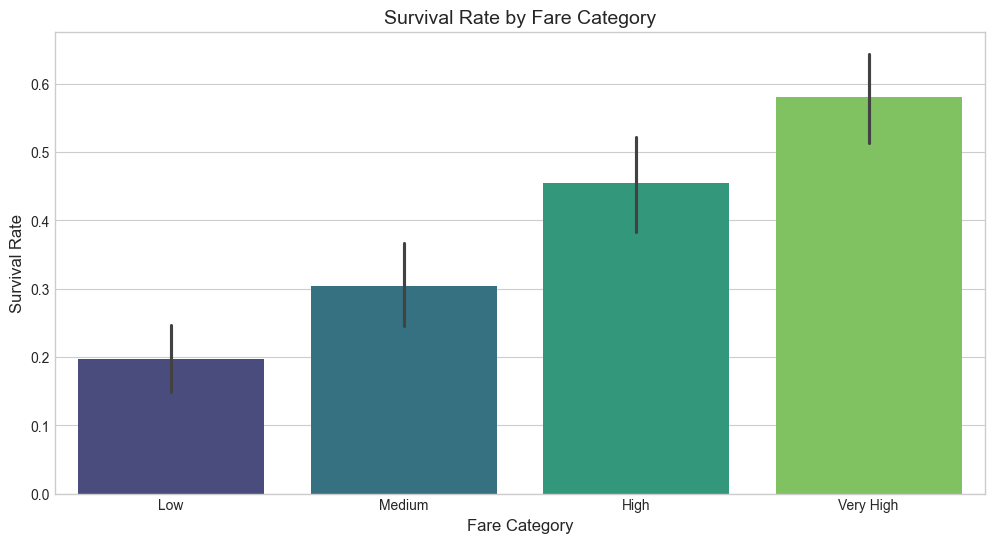

In [38]:
# Survival rate by Fare Category
plt.figure(figsize=(12, 6))
sns.barplot(x='FareCategory', y='Survived', data=df, estimator=np.mean, palette='viridis')
plt.title('Survival Rate by Fare Category', fontsize=14)
plt.xlabel('Fare Category', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.show()


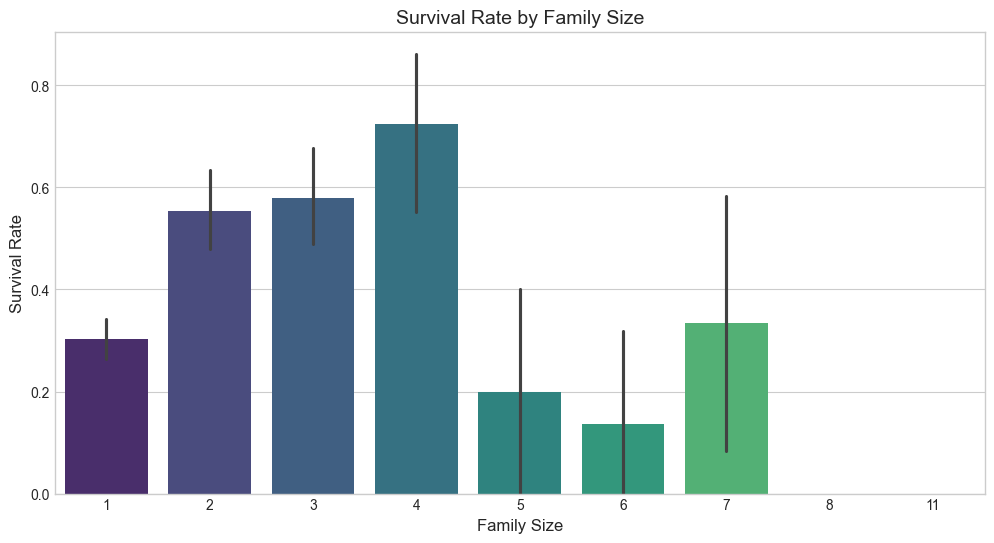

In [39]:
# Family Size feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 for the passenger themselves

# Survival rate by Family Size
plt.figure(figsize=(12, 6))
sns.barplot(x='FamilySize', y='Survived', data=df, estimator=np.mean, palette='viridis')
plt.title('Survival Rate by Family Size', fontsize=14)
plt.xlabel('Family Size', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.show()


# Excercise

In [ ]:
# EDA CHALLENGE

# INSTRUCTIONS:
# 1. Create an analysis that explores whether a passenger's title (Mr, Mrs, Miss, etc.)
#    affected their survival chances on the Titanic.
# 2. Extract titles from the Name column
# 3. Group similar titles (optional)
# 4. Create appropriate visualizations to show the relationship between title and survival
# 5. Calculate and interpret relevant statistics
# 6. Draw conclusions based on your findings

In [35]:
# Starter code to help you begin:
# Extract titles from passenger names
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

In [36]:
# Preview the titles you've extracted
print(df['Title'].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [41]:
# Your code goes below:
# 1. Group similar titles if needed (e.g., group rare titles)

title_map = {
    'Mr': 'Mr',
    'Miss': 'Miss',
    'Mlle': 'Miss',        # French equivalent of Miss
    'Ms': 'Miss',
    'Mrs': 'Mrs',
    'Mme': 'Mrs',           # French equivalent of Mrs
    'Master': 'Master',
    'Dr': 'Officer/Noble',
    'Rev': 'Officer/Noble',
    'Col': 'Officer/Noble',
    'Major': 'Officer/Noble',
    'Capt': 'Officer/Noble',
    'Jonkheer': 'Officer/Noble',
    'Don': 'Officer/Noble',
    'Sir': 'Officer/Noble',
    'Lady': 'Officer/Noble',
    'Countess': 'Officer/Noble',
}

df['TitleGroup'] = df['Title'].map(title_map)

# Check nothing got missed
print("Unmapped titles:", df[df['TitleGroup'].isna()]['Title'].unique())

print(df['TitleGroup'].value_counts())

Unmapped titles: []
TitleGroup
Mr               517
Miss             185
Mrs              126
Master            40
Officer/Noble     23
Name: count, dtype: int64


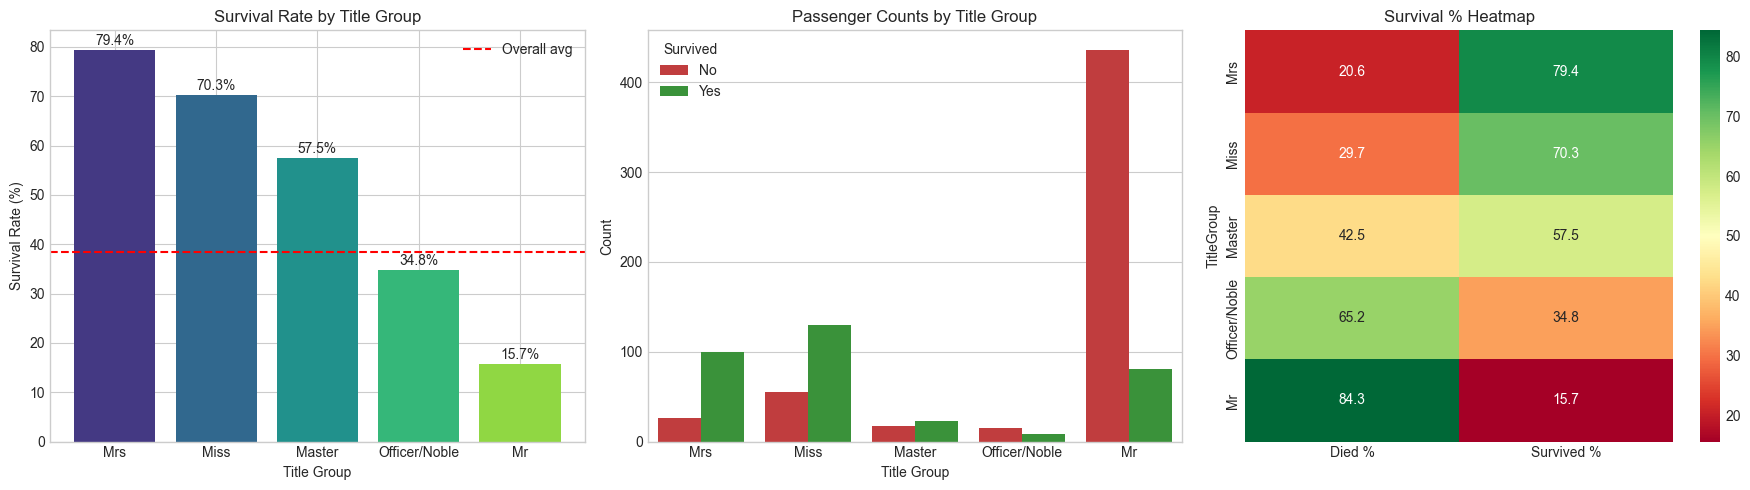

In [42]:
# 2. Create visualizations showing relationship between title and survival

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Survival rate (%) by title group ---
survival_rate = df.groupby('TitleGroup')['Survived'].mean().sort_values(ascending=False) * 100

ax = axes[0]
bars = ax.bar(survival_rate.index, survival_rate.values, color=sns.color_palette('viridis', len(survival_rate)))
ax.axhline(df['Survived'].mean() * 100, color='red', linestyle='--', label='Overall avg')
ax.set_title('Survival Rate by Title Group')
ax.set_ylabel('Survival Rate (%)')
ax.set_xlabel('Title Group')
ax.legend()
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1, f'{b.get_height():.1f}%', ha='center')

# --- Plot 2: Raw counts, survived vs died, per title group ---
ax = axes[1]
sns.countplot(data=df, x='TitleGroup', hue='Survived', order=survival_rate.index, ax=ax, palette=['#d62728', '#2ca02c'])
ax.set_title('Passenger Counts by Title Group')
ax.set_xlabel('Title Group')
ax.set_ylabel('Count')
ax.legend(title='Survived', labels=['No', 'Yes'])

# --- Plot 3: Heatmap of survival % ---
ax = axes[2]
heat_data = pd.crosstab(df['TitleGroup'], df['Survived'], normalize='index') * 100
heat_data.columns = ['Died %', 'Survived %']
heat_data = heat_data.loc[survival_rate.index]
sns.heatmap(heat_data, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax)
ax.set_title('Survival % Heatmap')

plt.tight_layout()
plt.show()

In [45]:
!pip install scipy

In [49]:
# 3. Calculate relevant statistics (survival rate by title)

# --- Survival rate, counts, and totals per title group ---
survival_stats = df.groupby('TitleGroup')['Survived'].agg(['mean', 'sum', 'count'])
survival_stats.columns = ['SurvivalRate', 'Survived', 'Total']
survival_stats['SurvivalRate'] = (survival_stats['SurvivalRate'] * 100).round(1)
survival_stats = survival_stats.sort_values('SurvivalRate', ascending=False)

print(survival_stats)

# --- Overall survival rate for comparison ---
overall_rate = df['Survived'].mean() * 100
print(f"\nOverall survival rate: {overall_rate:.1f}%")

               SurvivalRate  Survived  Total
TitleGroup                                  
Mrs                    79.4       100    126
Miss                   70.3       130    185
Master                 57.5        23     40
Officer/Noble          34.8         8     23
Mr                     15.7        81    517

Overall survival rate: 38.4%


In [52]:
# 4. Draw conclusions - what patterns do you observe?

## Key Findings

- **Title is strongly linked to survival.** Survival rates ranged from ~16% (Mr) 
  to ~79% (Mrs) a huge spread compared to the overall average of ~38%.

- **Women survived at much higher rates than men.** Mrs (79.4%) and Miss (70.3%) 
  both sit well above the ship-wide average, while Mr sits far below it (15.7%). 
  This lines up with the historical "women and children first" evacuation policy.

- **Boys (Master) did better than adult men, but not as well as women.** 
  Master had a 57.5% survival rate, clearly benefiting from being prioritized 
  as a child, but still lower than either female group.

- **Officer/Noble was a mixed bag (~35%).** This group combines adult male 
  professionals (Dr, Rev, Col, Major, Capt) who were held to the same 
  "men last" standard as Mr with a couple of high-status women (Lady, 
  Countess), which likely pulled the average up slightly compared to Mr alone.

- **Title is mostly a proxy for sex and age, not a cause on its own.** 
  Median age by group shows Master ≈ 3.5 years vs Mr ≈ 30 years, confirming 
  these titles cleanly separate demographic groups. The real driver behind 
  the survival gap is almost certainly the evacuation priority given to 
  women and children, with title acting as a convenient stand-in for that.

## Caveat
This is a descriptive/statistical pattern, not causal proof — title itself 
didn't cause survival; it correlates strongly with sex, age, and possibly 
class, which are the more direct factors.

SyntaxError: invalid character '—' (U+2014) (1172224937.py, line 13)

                      SurvivalRate  Count
TitleGroup    Pclass                     
Master        1              100.0      3
              2              100.0      9
              3               39.3     28
Miss          1               95.8     48
              2               94.3     35
              3               50.0    102
Mr            1               34.6    107
              2                8.8     91
              3               11.3    319
Mrs           1               97.7     43
              2               90.2     41
              3               50.0     42
Officer/Noble 1               53.3     15
              2                0.0      8


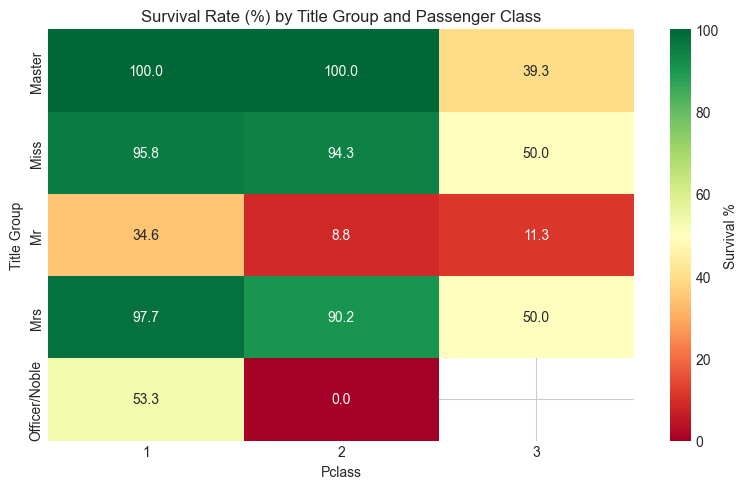

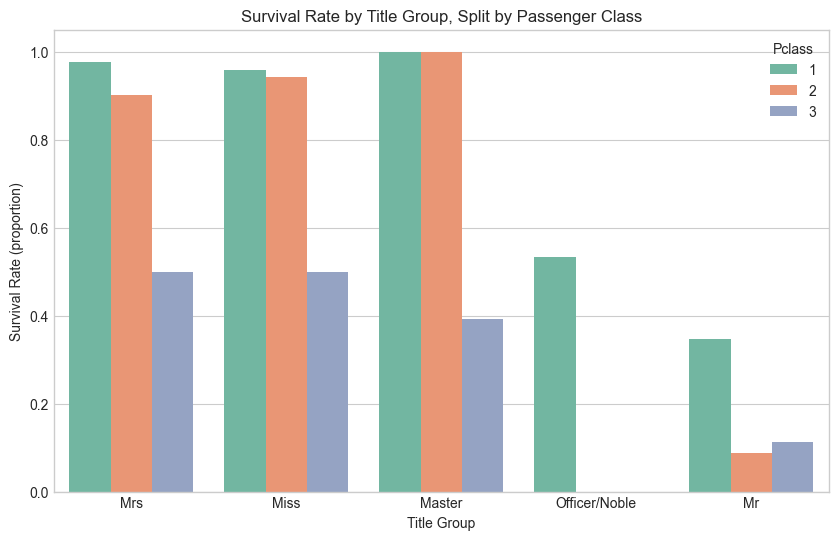

In [50]:
# BONUS:
# - Combine title with other features (like Pclass or Age) for deeper analysis
# - Create a visualization that shows this multi-factor relationship

# --- Survival rate by TitleGroup AND Pclass ---
title_class_stats = df.groupby(['TitleGroup', 'Pclass'])['Survived'].agg(['mean', 'count'])
title_class_stats.columns = ['SurvivalRate', 'Count']
title_class_stats['SurvivalRate'] = (title_class_stats['SurvivalRate'] * 100).round(1)
print(title_class_stats)

# --- Visualization: heatmap of survival rate by Title x Pclass ---
pivot = df.pivot_table(index='TitleGroup', columns='Pclass', values='Survived', aggfunc='mean') * 100

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', cbar_kws={'label': 'Survival %'})
plt.title('Survival Rate (%) by Title Group and Passenger Class')
plt.xlabel('Pclass')
plt.ylabel('Title Group')
plt.tight_layout()
plt.show()

# --- Visualization: grouped bar chart, same data ---
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='TitleGroup', y='Survived', hue='Pclass', 
            order=survival_stats.index, palette='Set2', errorbar=None)
plt.title('Survival Rate by Title Group, Split by Passenger Class')
plt.ylabel('Survival Rate (proportion)')
plt.xlabel('Title Group')
plt.legend(title='Pclass')
plt.show()